In [1]:
import gymnasium as gym

env_cart = gym.make('CartPole-v1')
env_cart.reset()
print("=== This is Obsevation/Action space, terminated and truncated for CartPole ===")

print("Observation space: ", env_cart.observation_space)
print("Action space: ", env_cart.action_space)

action = env_cart.action_space.sample() 

# Thực hiện hành động
next_observation, reward, terminated, truncated, info = env_cart.step(action)

print("Reward after 1 step: ", reward)
print("End condition:")
print("   - Terminated (fail/finish): ", terminated)
print("   - truncated (timeout/end steps): ", truncated)

env_mountain = gym.make('MountainCar')
env_mountain.reset()

print("\n=== This is Obsevation/Action space, terminated and truncated for MountainCar ===")

print("Observation space: ", env_mountain.observation_space)
print("Action space: ", env_mountain.action_space)

action = env_mountain.action_space.sample() 

# Thực hiện hành động
next_observation, reward, terminated, truncated, info = env_mountain.step(action)

print("Reward after 1 step: ", reward)
print("End condition:")
print("   - Terminated (fail/finish): ", terminated)
print("   - truncated (timeout/end steps): ", truncated)


=== This is Obsevation/Action space, terminated and truncated for CartPole ===
Observation space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
Reward after 1 step:  1.0
End condition:
   - Terminated (fail/finish):  False
   - truncated (timeout/end steps):  False

=== This is Obsevation/Action space, terminated and truncated for MountainCar ===
Observation space:  Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space:  Discrete(3)
Reward after 1 step:  -1.0
End condition:
   - Terminated (fail/finish):  False
   - truncated (timeout/end steps):  False


/mnt/WindowsD/Reinforcement Learning/labs/venv/lib/python3.14/site-packages/gymnasium/envs/registration.py:520: UserWarning: WARN: Using the latest versioned environment `MountainCar-v0` instead of the unversioned environment `MountainCar`.
  logger.warn(


### Observation Dimension (which agent can 'see')
  - *CartPole*: 4 dimension - Continues (Cart Position, Cart Velocity, Pole Angle, Pole Angular Velocity)
  - *MountainCar*: 2 dimension - Continues (*Position*: the car position in x axis (from -1.2 to  0.6) flag at 0.5; *Velocity*: velocity of the car )
### State space (all the environment)
  - *CartPole*: 4 dimension - Continues
  - *MountainCar*: 2 dimension - Continues
### Action space
  - *CartPole*: Discrete (2 option: left/right)
  - *MountainCar*: Descrete (3 option: left/nothing/right)
### How to compute the Reward ??
  - *CartPole*: +1 each time (hold stick verticaly as long as possible)
  - *MountainCar*: -1 each time (minimize the step take from ***bottom*** to ***top***)
### What is Episode ?
  - Episode is the series of action from ***Start*** to the ***end*** of turn (*terminated* (`dead` by rule) and *truncated* (`timeout`) is two variable define a turn) 


In [2]:
state, info = env_cart.reset()

done = False
total_reward = 0

while not done:
    action = env_cart.action_space.sample()  # random action

    next_state, reward, terminated, truncated, info = env_cart.step(action)

    done = terminated or truncated

    total_reward += reward

    print(f'Episode reward: {total_reward}, terminated: {terminated}, truncated: {truncated}')

Episode reward: 1.0, terminated: False, truncated: False
Episode reward: 2.0, terminated: False, truncated: False
Episode reward: 3.0, terminated: False, truncated: False
Episode reward: 4.0, terminated: False, truncated: False
Episode reward: 5.0, terminated: False, truncated: False
Episode reward: 6.0, terminated: False, truncated: False
Episode reward: 7.0, terminated: False, truncated: False
Episode reward: 8.0, terminated: False, truncated: False
Episode reward: 9.0, terminated: False, truncated: False
Episode reward: 10.0, terminated: False, truncated: False
Episode reward: 11.0, terminated: False, truncated: False
Episode reward: 12.0, terminated: False, truncated: False
Episode reward: 13.0, terminated: False, truncated: False
Episode reward: 14.0, terminated: False, truncated: False
Episode reward: 15.0, terminated: False, truncated: False
Episode reward: 16.0, terminated: True, truncated: False


In [3]:
state, info = env_mountain.reset()

done = False
total_reward = 0

while not done:
    action = env_mountain.action_space.sample()  # random action

    next_state, reward, terminated, truncated, info = env_mountain.step(action)

    done = terminated or truncated

    total_reward += reward

    print(f'Episode reward: {total_reward}, terminated: {terminated}, truncated: {truncated}')


Episode reward: -1.0, terminated: False, truncated: False
Episode reward: -2.0, terminated: False, truncated: False
Episode reward: -3.0, terminated: False, truncated: False
Episode reward: -4.0, terminated: False, truncated: False
Episode reward: -5.0, terminated: False, truncated: False
Episode reward: -6.0, terminated: False, truncated: False
Episode reward: -7.0, terminated: False, truncated: False
Episode reward: -8.0, terminated: False, truncated: False
Episode reward: -9.0, terminated: False, truncated: False
Episode reward: -10.0, terminated: False, truncated: False
Episode reward: -11.0, terminated: False, truncated: False
Episode reward: -12.0, terminated: False, truncated: False
Episode reward: -13.0, terminated: False, truncated: False
Episode reward: -14.0, terminated: False, truncated: False
Episode reward: -15.0, terminated: False, truncated: False
Episode reward: -16.0, terminated: False, truncated: False
Episode reward: -17.0, terminated: False, truncated: False
Episod

In [5]:
import numpy as np

episodes = 100
rewards_cartpole = []
rewards_mountaincar = []

for i in range(episodes):
    state, info = env_cart.reset()
    done = False
    total_reward = 0
    while not done:
        action = env_cart.action_space.sample()
        next_state, reward, terminated, truncated, info = env_cart.step(action)
        done = terminated or truncated
        total_reward += reward
    rewards_cartpole.append(total_reward)
    
    state, info = env_mountain.reset()
    done = False
    total_reward = 0
    while not done:
        action = env_mountain.action_space.sample()
        next_state, reward, terminated, truncated, info = env_mountain.step(action)
        done = terminated or truncated
        total_reward += reward
    rewards_mountaincar.append(total_reward)

print(f'CartPole: {np.mean(rewards_cartpole)}, MountainCar: {np.mean(rewards_mountaincar)}')

CartPole: 22.48, MountainCar: -200.0


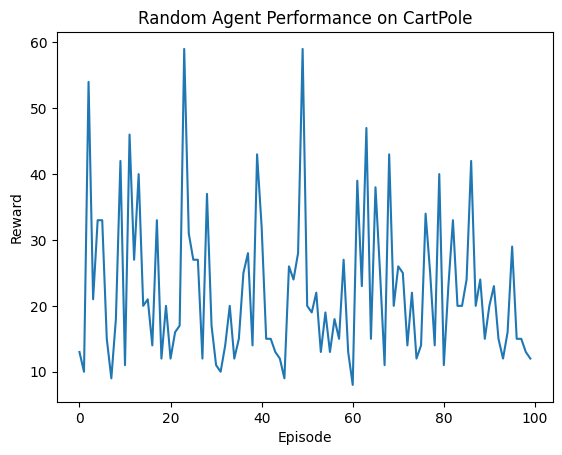

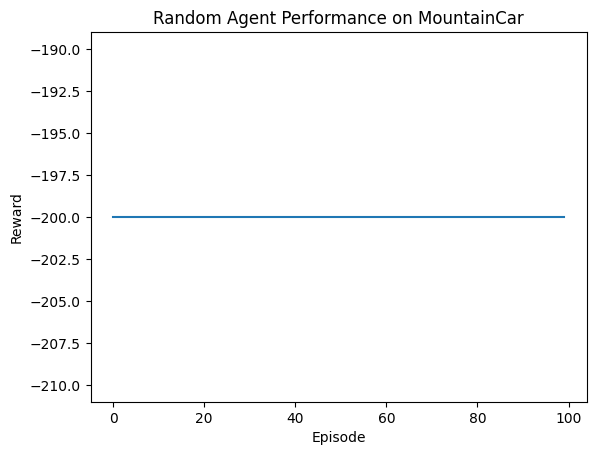

In [6]:
import matplotlib.pyplot as plt

plt.plot(rewards_cartpole)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance on CartPole")
plt.show()

plt.plot(rewards_mountaincar)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance on MountainCar")
plt.show()


### Average Reward
- CartPole: 22.48
- MountainCar: -200
### Trend over Time
- CartPole: No clear increasing trend. Rewards fluctuate randomly across episodes.
- MountainCar: No improvement over time. The agent consistently fails and reaches the step limit.
### Does the Random Agent Converge?
- CartPole: No. The random policy does not converge.
- MountainCar: No. The agent consistently fails to reach the goal.
### Why Do We Need a Learnable Policy?
A random policy cannot improve its performance because it does not learn from experience.  
A learnable policy enables the agent to update its behavior based on rewards and gradually achieve better performance.

MountainCar illustrates the difficulty of exploration in reinforcement learning,
where random actions are insufficient to discover the optimal strategy.